### Install required libraries

In case of a requirement of installing certain python libraries for use in your task, you may do so as shown below.


In [1]:
%pip install seaborn

Note: you may need to restart the kernel to use updated packages.


### Downloading the dataset

Execute the following code to download the dataset in to the interface.


In [2]:
import pandas as pd

# 1. Read the CSV file from URL
url = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMSkillsNetwork-AI0272EN-SkillsNetwork/labs/dataset/2016.csv"
df = pd.read_csv(url)

# 2. Print the first 5 rows
df.head()


,Country,Region,Happiness Rank,Happiness Score,Lower Confidence Interval,Upper Confidence Interval,Economy (GDP per Capita),Family,Health (Life Expectancy),Freedom,Trust (Government Corruption),Generosity,Dystopia Residual
0,Denmark,Western Europe,1,7.526,7.460,7.592,1.44178,1.16374,0.79504,0.57941,0.44453,0.36171,2.73939
1,Switzerland,Western Europe,2,7.509,7.428,7.59,1.52733,1.14524,0.86303,0.58557,0.41203,0.28083,2.69463
2,Iceland,Western Europe,3,7.501,7.333,7.669,1.42666,1.18326,0.86733,0.56624,0.14975,0.47678,2.83137
3,Norway,Western Europe,4,7.498,7.421,7.575,1.57744,1.12690,0.79579,0.59609,0.35776,0.37895,2.66465
4,Finland,Western Europe,5,7.413,7.351,7.475,1.40598,1.13464,0.81091,0.57104,0.41004,0.25492,2.82596


# Test Environment


In [3]:
# 1. List column data types and detect unsuitable ones
print("=== Original Data Types ===")
print(df.dtypes)

# Detect numeric-looking columns stored as object
unsuitable_cols = []
for col in df.columns:
    if df[col].dtype == "object":
        try:
            pd.to_numeric(df[col])
            unsuitable_cols.append(col)
        except:
            pass

print("\nColumns with unsuitable data types:")
print(unsuitable_cols)

# 2. Convert unsuitable columns to numeric
for col in unsuitable_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")

# 3. Display updated dataframe info
print("\n=== Updated df.info() ===")
df.info()


=== Original Data Types ===
Country                           object
Region                            object
Happiness Rank                     int64
Happiness Score                  float64
Lower Confidence Interval        float64
Upper Confidence Interval         object
Economy (GDP per Capita)          object
Family                           float64
Health (Life Expectancy)          object
Freedom                           object
Trust (Government Corruption)    float64
Generosity                       float64
Dystopia Residual                float64
dtype: object

Columns with unsuitable data types:
[]

=== Updated df.info() ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 157 entries, 0 to 156
Data columns (total 13 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Country                        157 non-null    object 
 1   Region                         157 non-null    object 
 2   Happines

In [4]:
# Convert all columns to float except 'Country' and 'Region'
for col in df.columns:
    if col not in ["Country", "Region"]:
        df[col] = pd.to_numeric(df[col], errors="coerce")


# Present df.info()
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 157 entries, 0 to 156
Data columns (total 13 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Country                        157 non-null    object 
 1   Region                         157 non-null    object 
 2   Happiness Rank                 157 non-null    int64  
 3   Happiness Score                157 non-null    float64
 4   Lower Confidence Interval      153 non-null    float64
 5   Upper Confidence Interval      154 non-null    float64
 6   Economy (GDP per Capita)       155 non-null    float64
 7   Family                         157 non-null    float64
 8   Health (Life Expectancy)       154 non-null    float64
 9   Freedom                        156 non-null    float64
 10  Trust (Government Corruption)  157 non-null    float64
 11  Generosity                     157 non-null    float64
 12  Dystopia Residual              157 non-null    flo

In [5]:
# 1. Identify columns with missing values and fill blanks with the mean
df = df.fillna(df.mean(numeric_only=True))

# 2. Display df.info()
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 157 entries, 0 to 156
Data columns (total 13 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Country                        157 non-null    object 
 1   Region                         157 non-null    object 
 2   Happiness Rank                 157 non-null    int64  
 3   Happiness Score                157 non-null    float64
 4   Lower Confidence Interval      157 non-null    float64
 5   Upper Confidence Interval      157 non-null    float64
 6   Economy (GDP per Capita)       157 non-null    float64
 7   Family                         157 non-null    float64
 8   Health (Life Expectancy)       157 non-null    float64
 9   Freedom                        157 non-null    float64
 10  Trust (Government Corruption)  157 non-null    float64
 11  Generosity                     157 non-null    float64
 12  Dystopia Residual              157 non-null    flo

In [6]:
#General statistical analysis of the data, getting a general understandin of the numbers. 
df.describe()


,Happiness Rank,Happiness Score,Lower Confidence Interval,Upper Confidence Interval,Economy (GDP per Capita),Family,Health (Life Expectancy),Freedom,Trust (Government Corruption),Generosity,Dystopia Residual
count,157.000000,157.000000,157.000000,157.000000,157.000000,157.000000,157.000000,157.000000,157.000000,157.000000,157.000000
mean,78.980892,5.382185,5.268641,5.472753,0.951772,0.793621,0.553342,0.370999,0.137624,0.242635,2.325807
std,45.466030,1.141674,1.136644,1.125458,0.410549,0.266706,0.227131,0.145507,0.111038,0.133756,0.542220
min,1.000000,2.905000,2.732000,3.078000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.817890
25%,40.000000,4.404000,4.327000,4.465000,0.670240,0.641840,0.382910,0.257480,0.061260,0.154570,2.031710
50%,79.000000,5.314000,5.268641,5.472753,1.024160,0.841420,0.594710,0.397470,0.105470,0.222450,2.290740
75%,118.000000,6.269000,6.073000,6.386000,1.276070,1.021520,0.717230,0.484530,0.175540,0.311850,2.664650
max,157.000000,7.526000,7.460000,7.669000,1.824270,1.183260,0.952770,0.608480,0.505210,0.819710,3.837720


In [7]:
#Analyzing the world happiness score by societies.
regions = df['Region'].unique()
regions

array(['Western Europe', 'North America', 'Australia and New Zealand',
       'Middle East and Northern Africa', 'Latin America and Caribbean',
       'Southeastern Asia', 'Central and Eastern Europe', 'Eastern Asia',
       'Sub-Saharan Africa', 'Southern Asia'], dtype=object)

In [8]:
#splitting world regions by societies, the west and the rest.
west = ['Western Europe', 'North America', 'Australia and New Zealand',
        'Latin America and Caribbean','Central and Eastern Europe']

rest = ['Middle East and Northern Africa','Southeastern Asia', 'Eastern Asia',
       'Sub-Saharan Africa', 'Southern Asia']

west_df = df[df['Region'].isin(west)]

rest_df = df[df['Region'].isin(rest)]

In [9]:
west_df['Region'].unique()

array(['Western Europe', 'North America', 'Australia and New Zealand',
       'Latin America and Caribbean', 'Central and Eastern Europe'],
      dtype=object)

In [10]:
rest_df['Region'].unique()

array(['Middle East and Northern Africa', 'Southeastern Asia',
       'Eastern Asia', 'Sub-Saharan Africa', 'Southern Asia'],
      dtype=object)

In [11]:
west_df.describe()

,Happiness Rank,Happiness Score,Lower Confidence Interval,Upper Confidence Interval,Economy (GDP per Capita),Family,Health (Life Expectancy),Freedom,Trust (Government Corruption),Generosity,Dystopia Residual
count,78.000000,78.000000,78.000000,78.000000,78.000000,78.000000,78.000000,78.000000,78.000000,78.000000,78.000000
mean,52.358974,6.048026,5.914127,6.118391,1.152427,0.934220,0.679220,0.399863,0.143413,0.233135,2.499155
std,35.215099,0.900565,0.909120,0.889762,0.266720,0.195670,0.126848,0.146296,0.119031,0.128681,0.473830
min,1.000000,4.028000,3.893000,4.163000,0.340970,0.192490,0.274940,0.058220,0.000000,0.000000,1.153770
25%,21.500000,5.493500,5.268641,5.478065,0.978800,0.812735,0.584442,0.291950,0.048785,0.140672,2.202410
50%,50.500000,5.976500,5.830000,6.064000,1.184775,1.006505,0.677070,0.428460,0.109515,0.219500,2.501280
75%,73.750000,6.764750,6.639000,6.802500,1.351845,1.065617,0.802435,0.522528,0.184780,0.298600,2.800900
max,136.000000,7.526000,7.460000,7.669000,1.697520,1.183260,0.878960,0.608480,0.444530,0.562370,3.559060


In [12]:
rest_df.describe()

,Happiness Rank,Happiness Score,Lower Confidence Interval,Upper Confidence Interval,Economy (GDP per Capita),Family,Health (Life Expectancy),Freedom,Trust (Government Corruption),Generosity,Dystopia Residual
count,79.000000,79.000000,79.000000,79.000000,79.000000,79.000000,79.000000,79.000000,79.000000,79.000000,79.000000
mean,105.265823,4.724772,4.631325,4.835288,0.753657,0.654802,0.429058,0.342501,0.131908,0.252015,2.154652
std,38.750917,0.961843,0.969529,0.960918,0.432271,0.255308,0.236227,0.139859,0.102983,0.138763,0.553759
min,11.000000,2.905000,2.732000,3.078000,0.000000,0.000000,0.000000,0.000000,0.003220,0.039360,0.817890
25%,81.000000,3.965000,3.867500,4.070500,0.388105,0.495830,0.241920,0.250120,0.070600,0.173320,1.934050
50%,113.000000,4.574000,4.425000,4.704000,0.740360,0.703620,0.398800,0.370999,0.103390,0.226860,2.150750
75%,137.500000,5.291000,5.218000,5.408500,1.059770,0.865455,0.619055,0.434095,0.158435,0.313700,2.420825
max,157.000000,7.267000,7.199000,7.335000,1.824270,1.089830,0.952770,0.588520,0.505210,0.819710,3.837720


In [13]:
###insights:
# 1. the mean GDP per Capita is 1.15 for the west, vs 0.75 for the rest. a big difference. 
# 2. the mean Happiness score for the west 6.04 vs 4.72 for the rest.
# 3. the mean Health (Life Expectancy) is much higher in the west 0.679 commpared to 0.429 for the rest.


In [14]:
# Task 3: EDA
# Scatter Plot of the rest
import plotly.express as px

fig_1 = px.scatter(
    rest_df,
    x="Economy (GDP per Capita)",
    y="Happiness Score",
    color="Region",
    hover_name="Country",
    title="Happiness Score vs GDP per Capita by Region - Non-Western Societies",
    opacity=0.8,
)

fig_1.show()

In [15]:
###insights  - 
# 1. Outliers - Israel's happiness score standsout above all other countries, 
#    even though it is locaed in the middle east, is has a western society- strengthening the narrative that western societies are happier. 
# 2. The countries with the highest GDP per Capita are not necessarily the happiest.
# 3. General Trend - there is crrelation between a country's economy and the happiness score 
#    - the higher the GDP the higher the the happiness score. 


In [16]:
# Task 3: EDA
# Scatter Plot of the west

fig_2 = px.scatter(
    west_df,
    x="Economy (GDP per Capita)",
    y="Happiness Score",
    color="Region",
    hover_name="Country",
    title="Happiness Score vs GDP per Capita by Region - Western Societies",
    opacity=0.8,
)

fig_2.show()


In [17]:
###insights - 
# 1. The General Trend presists - higher GDP usually results in a higher happiness score. 
# 2. Some Latin American Countries have a higher happiness score than what their GDP would suggest, pointing at a cultural effect.
# 3. North America & Aus - New Zealand are some of the western world leading societies and are at the top of happiness score

In [18]:
# Task 3: EDA
# Scatter Plot
fig_3 = px.scatter(
    df,
    x="Economy (GDP per Capita)",
    y="Happiness Score",
    color="Region",
    hover_name="Country",
    title="Happiness Score vs GDP per Capita by Region",
    opacity=0.8,
)

fig_3.show()


In [19]:
### insights  -
#1. most countries in the lower end of the happiness score, are from Sub-Shaharan Africa. 

In [20]:
# Task 3: Exploratory Data Analysis
# Bar Charts 
import plotly.express as px

# Top 10 countries by GDP per Capita
top10_gdp = df.nlargest(10, "Economy (GDP per Capita)")

fig_4 = px.bar(
    top10_gdp,
    x="Country",
    y="Economy (GDP per Capita)",
    title="Top 10 Countries – Economy (GDP per Capita)",
    labels={"Economy (GDP per Capita)": "GDP per Capita Score"},
    hover_data={"Economy (GDP per Capita)": True}
)

fig_4.update_layout(
    xaxis_tickangle=-45,
    height=500
)

fig_4.show()


In [21]:
#top 10 countries by happiness score
top10happy = df.nlargest(10,'Happiness Score')

fig_5 = px.bar(
    top10happy, 
    x = 'Country',
    y = 'Happiness Score',
    title="Top 10 Countries – Happiness Score",
    hover_data = {'Happiness Score':True}
)

fig_5.show()

In [22]:
### insights - 
# 1. 7 of the top 10 happiest countries are from Western Europe.
# 2. The difefrence between the 1st and 10th place is only 0.235 in the Happiness Score

In [23]:
# 3. Top 10 countries by Health (Life Expectancy)
top10_health = df.nlargest(10, "Health (Life Expectancy)")

fig_6 = px.bar(top10_health, 
      x='Country', 
      y="Health (Life Expectancy)", 
      title="Top 10 Countries – Health (Life Expectancy)", 
      hover_data = {'Health (Life Expectancy)': True})

fig_6.show()


In [24]:
# insight - top 4 countries with the highest Health (Life Expectency) score are from East Asia. 

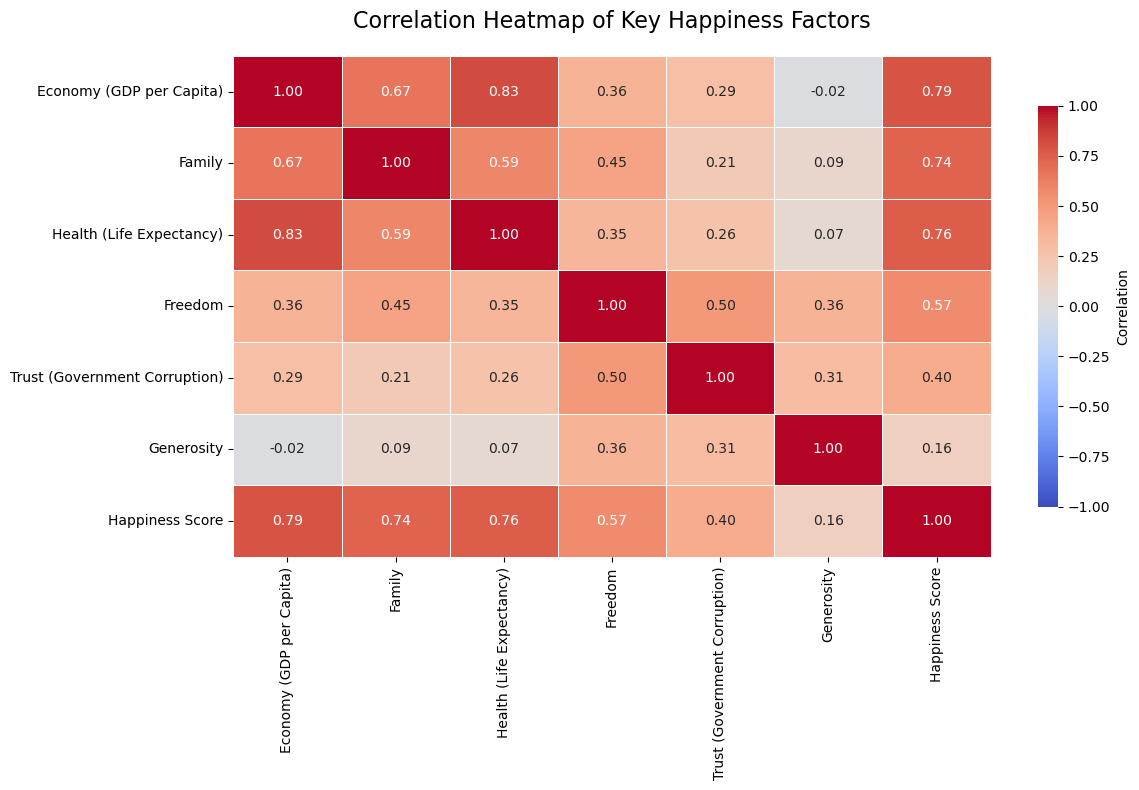

In [25]:
# Task 3: EDA
# Heatmap

import matplotlib.pyplot as plt
import seaborn as sns

# Select the columns for correlation
cols = [
    "Economy (GDP per Capita)",
    "Family",
    "Health (Life Expectancy)",
    "Freedom",
    "Trust (Government Corruption)",
    "Generosity",
    "Happiness Score"
]

# Compute correlation matrix
corr_matrix = df[cols].corr()

# Set figure size for readability
fig_7 = plt.figure(figsize=(12,8))

# Create a heatmap with annotations, custom color map, and improved aesthetics
sns.heatmap(
    corr_matrix,
    annot=True,               # show correlation values
    fmt=".2f",                # format to 2 decimals
    cmap="coolwarm",          # color map
    linewidths=0.5,           # lines between cells
    vmin=-1, vmax=1,          # correlation range
    cbar_kws={"shrink":0.8, "label":"Correlation"}
)

# Add title
plt.title("Correlation Heatmap of Key Happiness Factors", fontsize=16, pad=20)

# Display
plt.tight_layout()
plt.show()


In [26]:
### Insights - 
# 1. There is high correlation between a strong economy and Happiness score.
# 2. High correlation between the contribution of Family and Happiness score.
# 3. Healthier and longer life directly effect happiness. - Countries with strong Healthcare will generally be happier. 

In [27]:
# Task 3: EDA
# Pie Chart 

import plotly.express as px

# Group by Region and sum the Happiness Score
region_happiness = df.groupby("Region")["Happiness Score"].sum().reset_index()

# Create pie chart
fig_8 = px.pie(
    region_happiness,
    names="Region",
    values="Happiness Score",
    title="Total Happiness Score by Region",
    hole=0.3,  # optional: makes it a donut-style pie
)

fig_8.show()


In [28]:
# Task 3: EDA
# Map of GDP per Capita

import plotly.express as px

fig_9 = px.choropleth(
    df,
    locations="Country",  # Plotly recognizes country names automatically
    locationmode="country names",
    color="Economy (GDP per Capita)",
    hover_name="Country",
    hover_data={
        "Economy (GDP per Capita)": True,
        "Health (Life Expectancy)": True,
    },
    title="GDP per Capita by Country (with Healthy Life Expectancy Tooltip)",
    color_continuous_scale="Viridis"
)

fig_9.update_layout(
    geo=dict(showframe=False, showcoastlines=True),
    title_font=dict(size=22)
)

fig_9.show()


In [29]:

import plotly.io as pio
import base64
from io import BytesIO

# -------- Convert matplotlib heatmap to base64 --------
buf = BytesIO()
fig_7.savefig(buf, format="png", bbox_inches="tight", dpi=300)
buf.seek(0)
heatmap_base64 = base64.b64encode(buf.read()).decode("utf-8")

# -------- Convert Plotly figures to HTML snippets --------
fig3_html = pio.to_html(fig_3, full_html=False, include_plotlyjs='cdn')
fig1_html = pio.to_html(fig_1, full_html=False, include_plotlyjs=False)
fig5_html = pio.to_html(fig_5, full_html=False, include_plotlyjs=False)
fig9_html = pio.to_html(fig_9, full_html=False, include_plotlyjs=False)

# -------- Build PROFESSIONAL dashboard HTML --------
html = f"""
<!DOCTYPE html>
<html>
<head>
<meta charset="utf-8">
<title>Global Happiness Dashboard</title>

<style>
    body {{
        font-family: Arial, sans-serif;
        margin:0;
        background:#f4f6f9;
        text-align:center;
    }}

    h1 {{
        background:#0d6efd;
        color:white;
        padding:25px;
        margin:0;
    }}

    .container {{
        max-width:1100px;
        margin:auto;
        padding:30px;
    }}

    .card {{
        background:white;
        padding:25px;
        margin:35px 0;
        border-radius:14px;
        box-shadow:0 5px 18px rgba(0,0,0,0.15);
    }}

    img {{
        width:95%;
        border-radius:10px;
    }}
</style>
</head>

<body>

<h1>🌍 Global Happiness Dashboard</h1>

<div class="container">

    <div class="card">
        <h2>Correlation Heatmap</h2>
        <img src="data:image/png;base64,{heatmap_base64}">
    </div>

    <div class="card">
        <h2>GDP vs Happiness Score</h2>
        {fig3_html}
    </div>

    <div class="card">
        <h2>Non-Western Countries Analysis</h2>
        {fig1_html}
    </div>

    <div class="card">
        <h2>Top 10 Happiest Countries</h2>
        {fig5_html}
    </div>

    <div class="card">
        <h2>World GDP Choropleth</h2>
        {fig9_html}
    </div>

</div>

</body>
</html>
"""

# -------- Save file --------
with open("World_Happiness_Dashboard.html", "w", encoding="utf-8") as f:
    f.write(html)

print("✅ SUCCESS! Dashboard exported as World_Happiness_Dashboard.html")

✅ SUCCESS! Dashboard exported as World_Happiness_Dashboard.html
